In [86]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split as tts
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle

In [53]:
data=pd.read_csv('kidney_disease - kidney_disease.csv')

In [54]:
data

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [55]:
data1=data.drop(axis=1, columns='id')
data1

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [56]:
for i in data1.columns:
    data_uni = data1[i].unique()
    data_list = [str(v) for v in data_uni]
    print(f'{i}:{data_list}')

age:['48.0', '7.0', '62.0', '51.0', '60.0', '68.0', '24.0', '52.0', '53.0', '50.0', '63.0', '40.0', '47.0', '61.0', '21.0', '42.0', '75.0', '69.0', 'nan', '73.0', '70.0', '65.0', '76.0', '72.0', '82.0', '46.0', '45.0', '35.0', '54.0', '11.0', '59.0', '67.0', '15.0', '55.0', '44.0', '26.0', '64.0', '56.0', '5.0', '74.0', '38.0', '58.0', '71.0', '34.0', '17.0', '12.0', '43.0', '41.0', '57.0', '8.0', '39.0', '66.0', '81.0', '14.0', '27.0', '83.0', '30.0', '4.0', '3.0', '6.0', '32.0', '80.0', '49.0', '90.0', '78.0', '19.0', '2.0', '33.0', '36.0', '37.0', '23.0', '25.0', '20.0', '29.0', '28.0', '22.0', '79.0']
bp:['80.0', '50.0', '70.0', '90.0', 'nan', '100.0', '60.0', '110.0', '140.0', '180.0', '120.0']
sg:['1.02', '1.01', '1.005', '1.015', 'nan', '1.025']
al:['1.0', '4.0', '2.0', '3.0', '0.0', 'nan', '5.0']
su:['0.0', '3.0', '4.0', '1.0', 'nan', '2.0', '5.0']
rbc:['nan', 'normal', 'abnormal']
pc:['normal', 'abnormal', 'nan']
pcc:['notpresent', 'present', 'nan']
ba:['notpresent', 'present'

In [57]:
cat_col=['rbc','pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
for i in cat_col:
    data1[i]=data1[i].fillna(data1[i].mode())

In [58]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             249 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [59]:
import numpy as np
for i in data1.columns:
    data1[i]=data1[i].replace(['?','NAN'], np.nan)

In [60]:
con_col=['age', 'bp', 'sg', 'al', 'su', 'bgr',  'bu', 'sc', 'sod',  'pot', 'hemo', 'pcv', 'wc', 'rc' ]
for i in con_col:
    data1[i]=pd.to_numeric(data1[i], errors='coerce')
    data1[i]=data1[i].fillna(round(data1[i].mean(), 2))

In [61]:
for i in data1.columns:
    data1_uni=data1[i].unique()
    data1_list=[str(k) for k in data1_uni]
    print(f'{i}:{data1_list}')

age:['48.0', '7.0', '62.0', '51.0', '60.0', '68.0', '24.0', '52.0', '53.0', '50.0', '63.0', '40.0', '47.0', '61.0', '21.0', '42.0', '75.0', '69.0', '51.48', '73.0', '70.0', '65.0', '76.0', '72.0', '82.0', '46.0', '45.0', '35.0', '54.0', '11.0', '59.0', '67.0', '15.0', '55.0', '44.0', '26.0', '64.0', '56.0', '5.0', '74.0', '38.0', '58.0', '71.0', '34.0', '17.0', '12.0', '43.0', '41.0', '57.0', '8.0', '39.0', '66.0', '81.0', '14.0', '27.0', '83.0', '30.0', '4.0', '3.0', '6.0', '32.0', '80.0', '49.0', '90.0', '78.0', '19.0', '2.0', '33.0', '36.0', '37.0', '23.0', '25.0', '20.0', '29.0', '28.0', '22.0', '79.0']
bp:['80.0', '50.0', '70.0', '90.0', '76.47', '100.0', '60.0', '110.0', '140.0', '180.0', '120.0']
sg:['1.02', '1.01', '1.005', '1.015', '1.025']
al:['1.0', '4.0', '2.0', '3.0', '0.0', '1.02', '5.0']
su:['0.0', '3.0', '4.0', '1.0', '0.45', '2.0', '5.0']
rbc:['normal', 'nan', 'abnormal']
pc:['normal', 'abnormal', 'nan']
pcc:['notpresent', 'present', 'nan']
ba:['notpresent', 'present',

In [62]:
encode=['rbc','pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
LE=LabelEncoder()
for i in encode:
    data1[i]=LE.fit_transform(data1[i])

In [63]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int64  
 6   pc              400 non-null    int64  
 7   pcc             400 non-null    int64  
 8   ba              400 non-null    int64  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

In [64]:
data1

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.00,...,44.0,7800.0,5.20,1,1,0,0,0,0,ckd
1,7.0,50.0,1.020,4.0,0.0,2,1,0,0,148.04,...,38.0,6000.0,4.71,0,0,0,0,0,0,ckd
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.00,...,31.0,7500.0,4.71,0,1,0,1,0,1,ckd
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.00,...,32.0,6700.0,3.90,1,0,0,1,1,1,ckd
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.00,...,35.0,7300.0,4.60,0,0,0,0,0,0,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,1,1,0,0,140.00,...,47.0,6700.0,4.90,0,0,0,0,0,0,notckd
396,42.0,70.0,1.025,0.0,0.0,1,1,0,0,75.00,...,54.0,7800.0,6.20,0,0,0,0,0,0,notckd
397,12.0,80.0,1.020,0.0,0.0,1,1,0,0,100.00,...,49.0,6600.0,5.40,0,0,0,0,0,0,notckd
398,17.0,60.0,1.025,0.0,0.0,1,1,0,0,114.00,...,51.0,7200.0,5.90,0,0,0,0,0,0,notckd


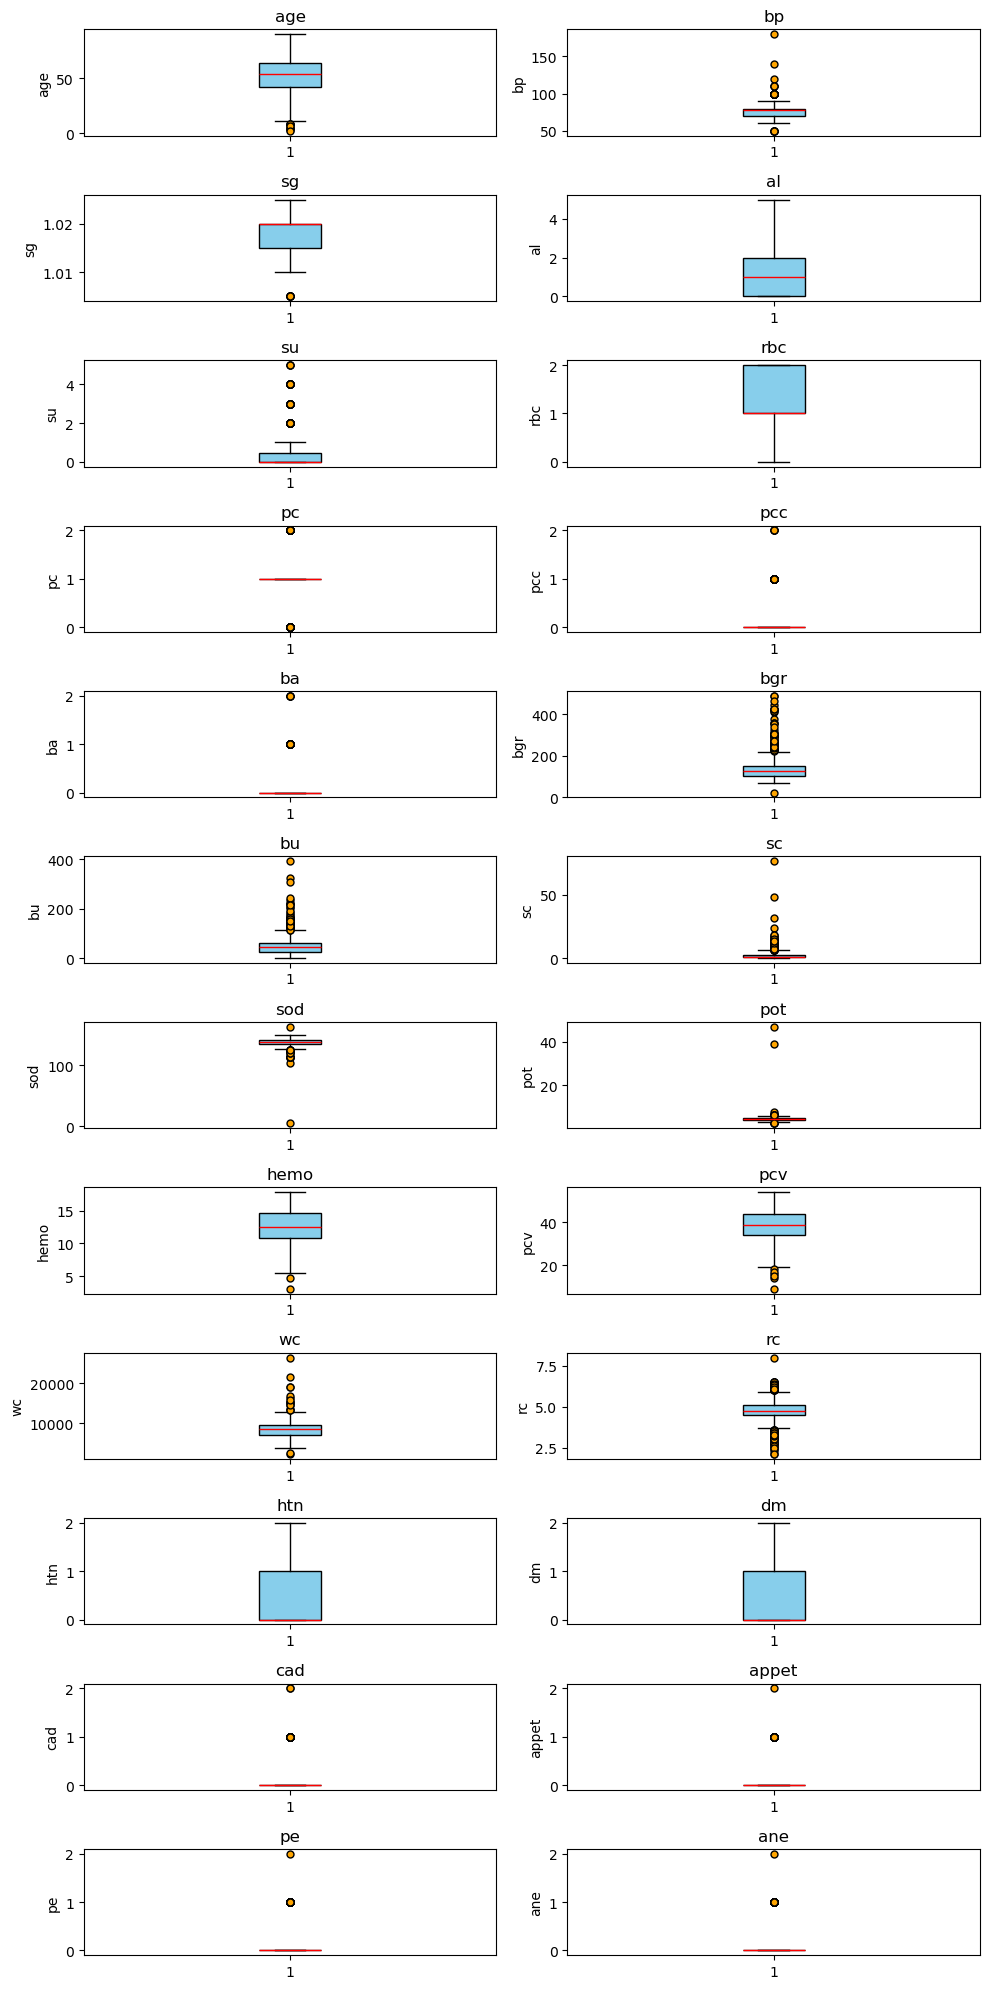

In [65]:
out_col=['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane']
plot = 2
row = len(out_col)
plotting= (row+plot -1)//plot
plt.figure(figsize=(10,20))
for i, col in enumerate(out_col, 1):
    plt.subplot( plotting, plot, i)
    plt.boxplot(data1[col], patch_artist=True, boxprops=dict(facecolor = 'skyblue'), whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='red'), flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
    plt.title(col)
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [66]:
outliers = ['age', 'bp', 'sg', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

def out_lier(df, coln):
    Q1 = df[coln].quantile(0.25)
    Q3 = df[coln].quantile(0.75)
    iqr = Q3 - Q1
    lower = Q1 - 1.5 * iqr
    upper = Q3 + 1.5 * iqr
    df[coln] = df[coln].clip(lower=lower, upper=upper)
    return df

for col in outliers:
    if col in data1.columns:
        data1 = out_lier(data1, col)
        print(f'{col} → outliers handled')
    else:
        print(f'{col} not found in data1')

age → outliers handled
bp → outliers handled
sg → outliers handled
su → outliers handled
bgr → outliers handled
bu → outliers handled
sc → outliers handled
sod → outliers handled
pot → outliers handled
hemo → outliers handled
pcv → outliers handled
wc → outliers handled
rc → outliers handled


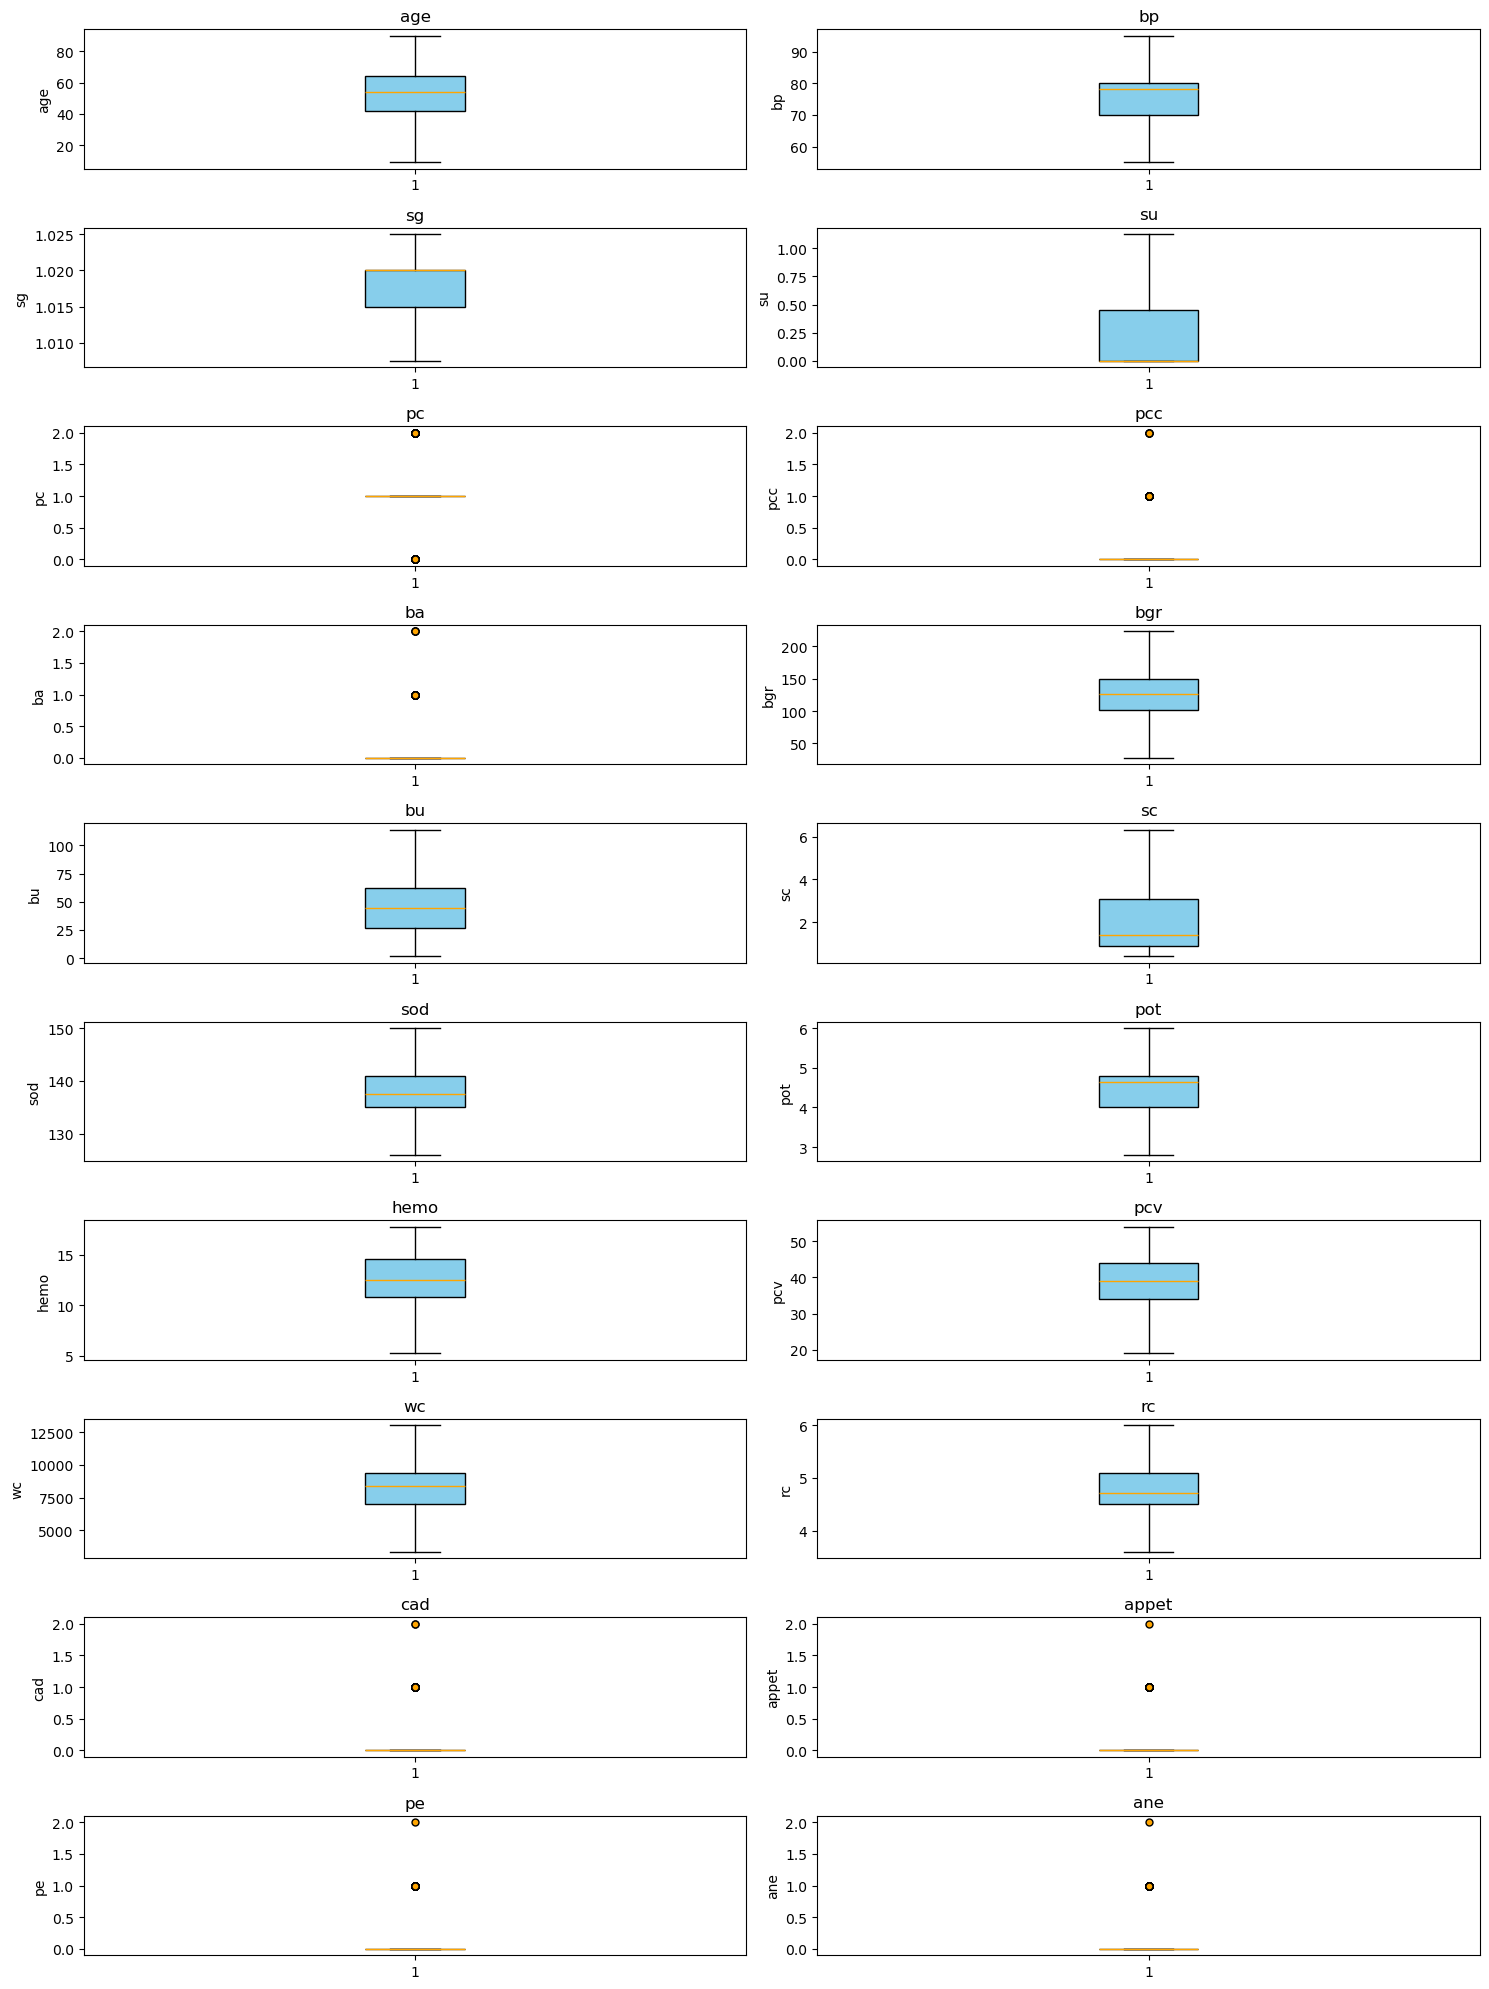

In [67]:
outliers=['age', 'bp', 'sg', 'su', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'cad', 'appet', 'pe', 'ane']
plot=2
no = len(outliers)
plotting = (no+plot-1)//plot
plt.figure(figsize=(15, 20))
for i, colnm in enumerate(outliers, 1):
    plt.subplot(plotting, plot, i)
    plt.boxplot(data1[colnm], patch_artist=True, boxprops=dict(facecolor='skyblue'), medianprops=dict(color='orange'), capprops=dict(color='black'), whiskerprops=dict(color='black'),  flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
    plt.title(colnm)
    plt.ylabel(colnm)
plt.tight_layout()
plt.show()

In [68]:
data1

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.0200,1.0,0.000,1,1,0,0,121.00,...,44.0,7800.0,5.20,1,1,0,0,0,0,ckd
1,9.0,55.0,1.0200,4.0,0.000,2,1,0,0,148.04,...,38.0,6000.0,4.71,0,0,0,0,0,0,ckd
2,62.0,80.0,1.0100,2.0,1.125,1,1,0,0,223.50,...,31.0,7500.0,4.71,0,1,0,1,0,1,ckd
3,48.0,70.0,1.0075,4.0,0.000,1,0,1,0,117.00,...,32.0,6700.0,3.90,1,0,0,1,1,1,ckd
4,51.0,80.0,1.0100,2.0,0.000,1,1,0,0,106.00,...,35.0,7300.0,4.60,0,0,0,0,0,0,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.0200,0.0,0.000,1,1,0,0,140.00,...,47.0,6700.0,4.90,0,0,0,0,0,0,notckd
396,42.0,70.0,1.0250,0.0,0.000,1,1,0,0,75.00,...,54.0,7800.0,6.00,0,0,0,0,0,0,notckd
397,12.0,80.0,1.0200,0.0,0.000,1,1,0,0,100.00,...,49.0,6600.0,5.40,0,0,0,0,0,0,notckd
398,17.0,60.0,1.0250,0.0,0.000,1,1,0,0,114.00,...,51.0,7200.0,5.90,0,0,0,0,0,0,notckd


In [69]:
ss_col = ['age', 'bp', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc',
       'pot', 'wc', 'htn', 'dm', 'cad', 'pe', 'ane']
SS = StandardScaler()
data1[ss_col] = SS.fit_transform(data1[ss_col])

In [70]:
data1

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,-0.213321,0.391529,1.0200,-0.013614,-0.557226,-0.397700,0.046368,-0.347524,-0.250873,-0.347729,...,44.0,-0.235168,5.20,1.257656,1.326566,-0.306651,0,-0.484519,-0.420341,ckd
1,-2.544830,-1.894961,1.0200,2.347239,-0.557226,1.131917,0.046368,-0.347524,-0.250873,0.240461,...,38.0,-1.123124,4.71,-0.762675,-0.722185,-0.306651,0,-0.484519,-0.420341,ckd
2,0.623631,0.391529,1.0100,0.773337,2.258626,-0.397700,0.046368,-0.347524,-0.250873,1.881912,...,31.0,-0.383161,4.71,-0.762675,1.326566,-0.306651,1,-0.484519,2.291539,ckd
3,-0.213321,-0.523067,1.0075,2.347239,-0.557226,-0.397700,-1.639745,2.432668,-0.250873,-0.434740,...,32.0,-0.777808,3.90,1.257656,-0.722185,-0.306651,1,2.000193,2.291539,ckd
4,-0.033974,0.391529,1.0100,0.773337,-0.557226,-0.397700,0.046368,-0.347524,-0.250873,-0.674019,...,35.0,-0.481822,4.60,-0.762675,-0.722185,-0.306651,0,-0.484519,-0.420341,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.205155,0.391529,1.0200,-0.800565,-0.557226,-0.397700,0.046368,-0.347524,-0.250873,0.065570,...,47.0,-0.777808,4.90,-0.762675,-0.722185,-0.306651,0,-0.484519,-0.420341,notckd
396,-0.572015,-0.523067,1.0250,-0.800565,-0.557226,-0.397700,0.046368,-0.347524,-0.250873,-1.348349,...,54.0,-0.235168,6.00,-0.762675,-0.722185,-0.306651,0,-0.484519,-0.420341,notckd
397,-2.365483,0.391529,1.0200,-0.800565,-0.557226,-0.397700,0.046368,-0.347524,-0.250873,-0.804534,...,49.0,-0.827139,5.40,-0.762675,-0.722185,-0.306651,0,-0.484519,-0.420341,notckd
398,-2.066572,-1.437663,1.0250,-0.800565,-0.557226,-0.397700,0.046368,-0.347524,-0.250873,-0.499998,...,51.0,-0.531153,5.90,-0.762675,-0.722185,-0.306651,0,-0.484519,-0.420341,notckd


In [71]:
X = data1.drop(["sg","sod","hemo","pcv","rc","appet","classification"], axis=1)
Y = data1["classification"]

In [72]:
Y.value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [73]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(X,Y)

In [74]:
x_resampled=pd.DataFrame(x_resampled, columns=X.columns)
y_resampled=pd.Series(y_resampled, name = "classification") 

In [75]:
x_train, x_test, y_train, y_test=tts(x_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
resam = x_resampled.copy()
resam['classification']=y_resampled
resam.to_csv('sampleing_data.csv', index=False)

In [76]:
check = pd.read_csv('sampleing_data.csv')
print(check['classification'].value_counts())

classification
ckd       250
notckd    250
Name: count, dtype: int64


In [77]:
y_resampled.value_counts()

classification
ckd       250
notckd    250
Name: count, dtype: int64

In [78]:
RFC = RandomForestClassifier(n_estimators=100, random_state=42)
RFC.fit(x_train, y_train)
y_pred = RFC.predict(x_test)

In [85]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f'accuracy score:{round(accuracy_score(y_pred, y_test))}')

              precision    recall  f1-score   support

         ckd       0.96      1.00      0.98        50
      notckd       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

[[50  0]
 [ 2 48]]
accuracy score:0.98


In [88]:
pickle.dump(RFC, open('kidney.pkl', 'wb'))